In [1]:
_repo_root = !git rev-parse --show-toplevel
%cd {_repo_root[0]}
del _repo_root

/Users/alex.shtoff/git/spectral_neuron_paper


# Criteo scaling

Validation-selected test performance after one-pass Adam/SparseAdam training. The plots separate parameter-matched model comparison, preprocessing comparison, and dimension scaling. Lower is better.

## Setup

In [2]:
import warnings

import matplotlib as mpl
import pandas as pd
from tqdm import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

from paper.experiments.criteo_scaling import (
    PROFILES,
    RAW_COLUMNS,
    default_raw_path,
    select_lr,
    summarize_raw,
)
from paper.plotting import (
    plot_criteo_models_by_dimension,
    plot_criteo_fm_dimensions,
    plot_criteo_spectral_comparison,
    plot_criteo_spectral_dimensions,
)

mpl.rcParams["figure.dpi"] = 140

In [3]:
profile_name = "full"
profile = PROFILES[profile_name]
raw_path = default_raw_path(profile_name)
metric = "logloss"

## Load and validate results

Preprocessing is fitted once on a fixed 10% sample of the training split. Learning rates are selected using validation loss; test metrics are then reported only for the selected trajectories.

In [4]:
if not raw_path.exists():
    raise FileNotFoundError(
        f"{raw_path} does not exist; run paper.experiments.criteo_scaling first"
    )

raw = pd.read_csv(raw_path)
if list(raw) != RAW_COLUMNS:
    raise ValueError(f"{raw_path} has an incompatible result schema")
if set(raw["protocol"]) != {"one_pass"}:
    raise ValueError(f"{raw_path} is not a one-pass scaling run")
if set(raw["optimizer"]) != {"adam+sparseadam"}:
    raise ValueError(f"{raw_path} is not an Adam/SparseAdam scaling run")

expected_models = {
    "linear", "linear-new", "fm", "spectral-old", "spectral-new"
}
if set(raw["model"]) != expected_models:
    raise ValueError(f"{raw_path} does not contain exactly {sorted(expected_models)}")
if set(raw["train_size"]) != set(profile.train_sizes):
    raise ValueError(f"{raw_path} does not match the {profile_name!r} profile")

selected = select_lr(raw)
if selected[["test_logloss", "test_brier"]].isna().any().any():
    raise ValueError(f"{raw_path} has incomplete selected test results")

summary = summarize_raw(raw)
summary[[
    "train_size",
    "model",
    "dim",
    "selected_lr",
    "median_test_logloss",
    "median_test_brier",
    "n",
]].sort_values(["train_size", "dim", "model"])

,train_size,model,dim,selected_lr,median_test_logloss,median_test_brier,n
3,4096,linear,0,0.026827,0.565706,0.189291,24
4,4096,linear-new,0,0.051795,0.550402,0.183795,24
0,4096,fm,3,0.013895,0.652172,0.229590,24
5,4096,spectral-new,3,0.051795,0.575086,0.191671,24
8,4096,spectral-old,3,0.026827,0.591618,0.199753,24
...,...,...,...,...,...,...,...
72,16777216,spectral-new,7,0.001000,0.459661,0.149310,24
75,16777216,spectral-old,7,0.001000,0.459357,0.149211,24
68,16777216,fm,11,0.001000,0.458309,0.148844,24
73,16777216,spectral-new,11,0.001000,0.460135,0.149496,24


## All models within each dimension

Each facet compares linear, linear-new, FM, spectral-old, and spectral-new. FM rank is matched to the spectral matrix parameter count; the two dimensionless linear curves are repeated for reference.

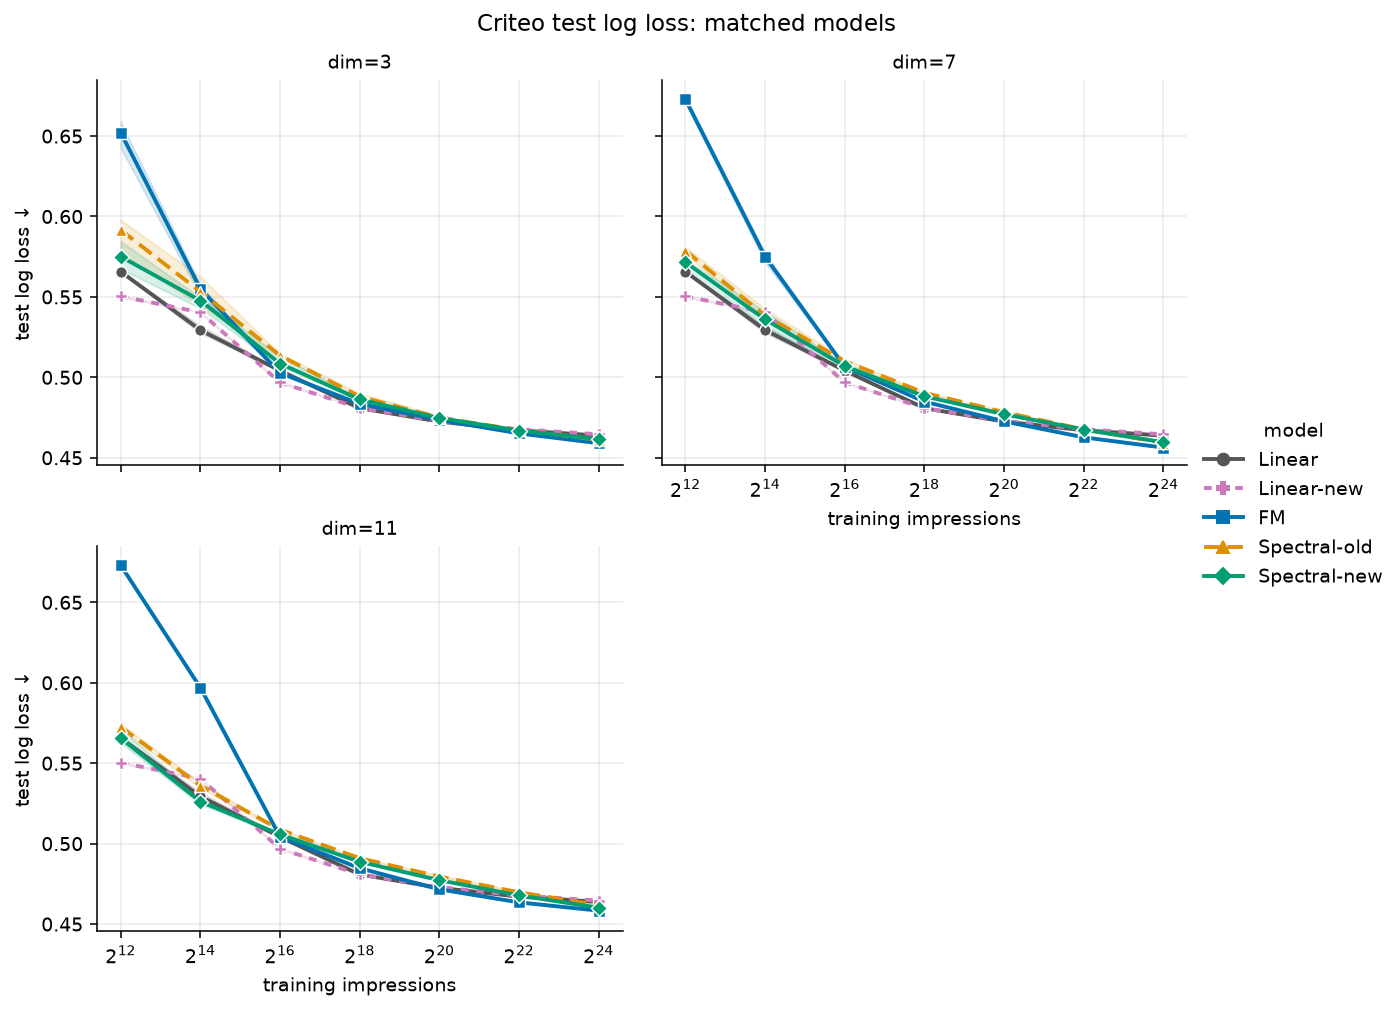

In [5]:
plot_criteo_models_by_dimension(selected, metric=metric);

## Spectral preprocessing within each dimension

This view removes the linear and FM references to isolate the effect of the numerical representation.

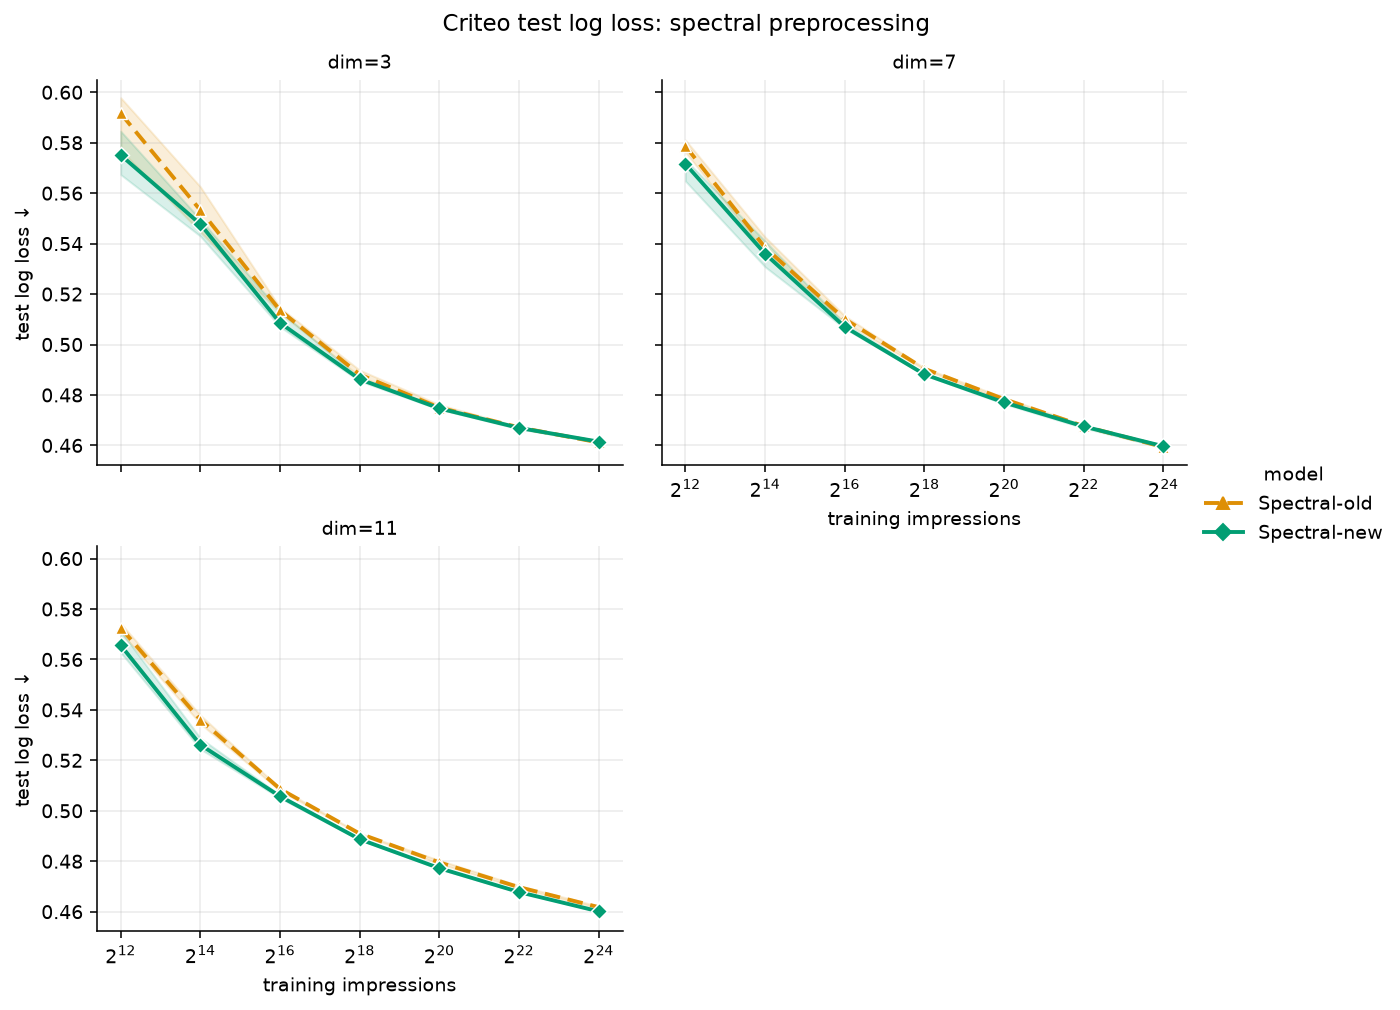

In [6]:
plot_criteo_spectral_comparison(selected, metric=metric);

## Spectral-new across dimensions

All hybrid-preprocessed spectral capacities on one axis.

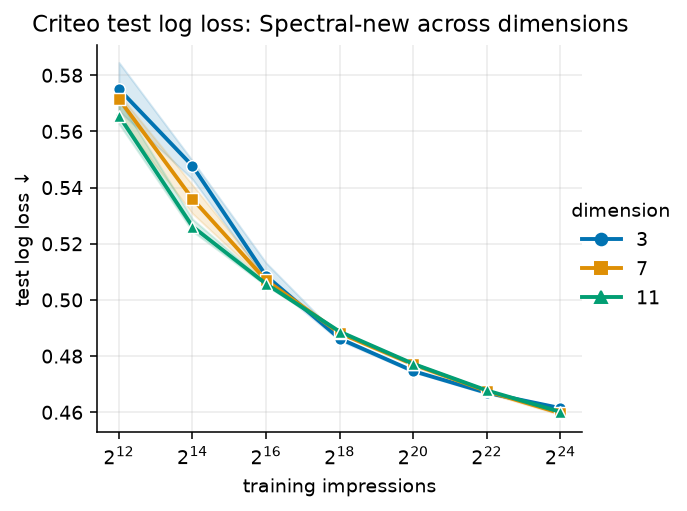

In [7]:
plot_criteo_spectral_dimensions(
    selected, "spectral-new", metric=metric
);

### Spectral-new detail from $2^{18}$ to $2^{20}$

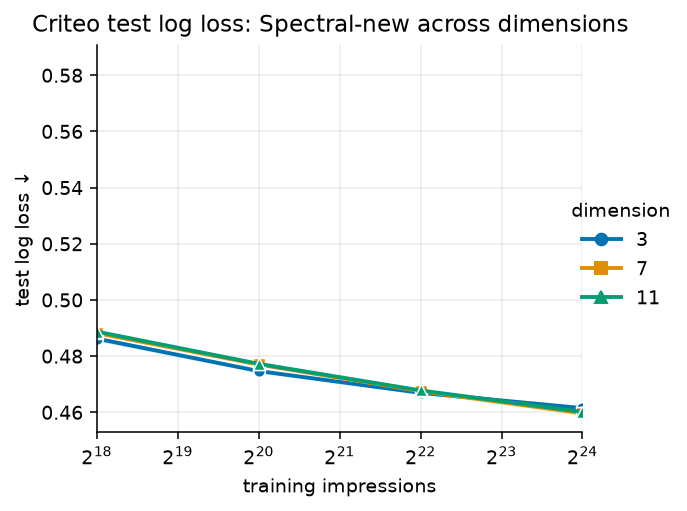

In [11]:
plot_criteo_spectral_dimensions(
    selected,
    "spectral-new",
    metric=metric,
    xlim=(2**18, 2**24),
);

## FM across embedding dimensions

Compare the parameter-matched FM embedding ranks across the full scaling range.

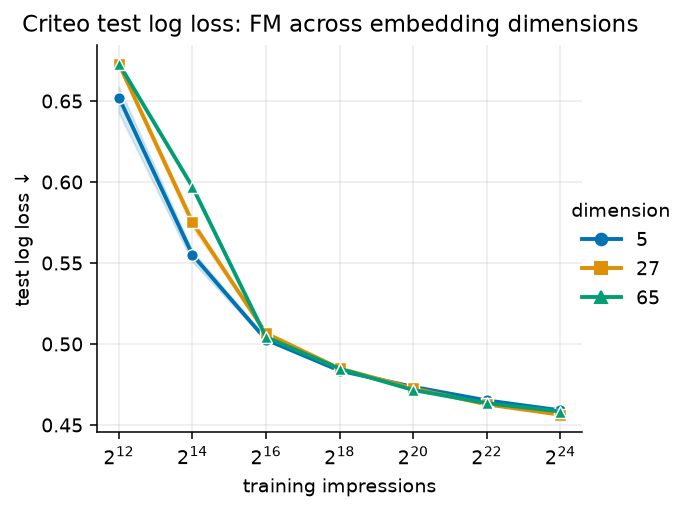

In [9]:
plot_criteo_fm_dimensions(selected, metric=metric);

## Spectral-old across dimensions

All bucket-preprocessed spectral capacities on one axis.

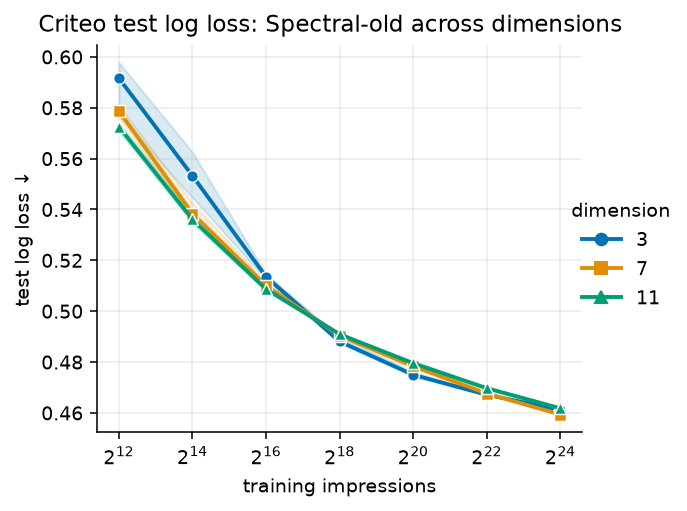

In [10]:
plot_criteo_spectral_dimensions(
    selected, "spectral-old", metric=metric
);

## Reading the comparison

The first two figures hold dimension fixed, so old and new spectral neurons have the same matrix parameter count. The spectral dimension views hold preprocessing fixed, while the FM view varies embedding rank. Lines are medians across retraining runs and bands span the 25th to 75th percentiles.

In this run, Spectral-new with dimension 15 beats dimension 3 by about 0.015 log loss at $2^{11}$ impressions and 0.012 at $2^{15}$. The spread falls below 0.002 by $2^{17}$ and then reverses slightly. FM does not share the low-data effect: rank 5 is best through $2^{15}$, the ranks converge near $2^{17}$, and rank 44 is best at the largest budget while rank 119 degrades.

The zoom covers $2^{18}$ to $2^{20}$, but the current profile has only one checkpoint inside that interval, at $2^{19}$; the visible curve segments interpolate between the neighboring checkpoints. Change `metric` in Setup to `"brier"` for the corresponding Brier-score views.